In [ ]:
# ============================================================================
# SECTION 1: INSTALL PACKAGES
# ============================================================================
print("\n[1/7] Installing required packages...")
import subprocess
import sys

packages = [
    'transformers',
    'accelerate',
    'bitsandbytes',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'pandas',
    'numpy'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ Packages installed!")



[1/7] Installing required packages...
✓ Packages installed!


In [ ]:
# ============================================================================
# SECTION 2: IMPORTS
# ============================================================================
print("\n[2/7] Importing libraries...")
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import time
import json
import gc
import warnings
import re
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



[2/7] Importing libraries...
✓ Libraries imported!
PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================================================
# SECTION 3: LOAD DATASET
# ============================================================================
print("\n[3/7] Upload your dataset...")

from google.colab import files
print("Please upload your CIC InvesAndMal2019 CSV file:")
uploaded = files.upload()

csv_filename = list(uploaded.keys())[0]
print(f"\n✓ File uploaded: {csv_filename}")

df = pd.read_csv(csv_filename)
print(f"✓ Dataset loaded! Shape: {df.shape}")


[3/7] Upload your dataset...
Please upload your CIC InvesAndMal2019 CSV file:


Saving StaticLayer_Intent_and_Permission_Bening&malware_TestingSmaples.csv to StaticLayer_Intent_and_Permission_Bening&malware_TestingSmaples.csv

✓ File uploaded: StaticLayer_Intent_and_Permission_Bening&malware_TestingSmaples.csv
✓ Dataset loaded! Shape: (634, 8115)



[4/7] Enhanced data preprocessing...
✓ Target column: '<category>'
✓ Classes (6): ['Adware', 'Benign', 'PremiumSMS', 'Ransomware', 'Scareware', 'SMS']

Class Distribution:
<category>
Benign        474
Scareware      41
Adware         38
Ransomware     37
SMS            24
PremiumSMS     20
Name: count, dtype: int64


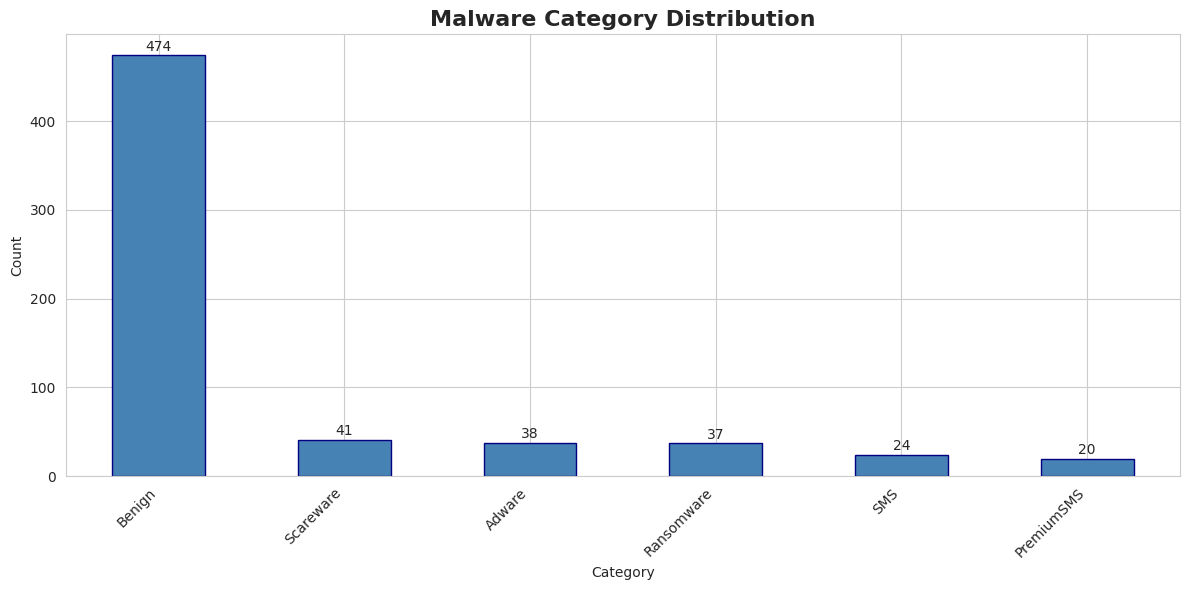


✓ Feature columns: 8112

✓ Label encoding complete
  0: Adware
  1: Benign
  2: PremiumSMS
  3: Ransomware
  4: SMS
  5: Scareware

✓ Selected top 50 most informative features


In [ ]:
# ============================================================================
# SECTION 4: IMPROVED DATA PREPROCESSING
# ============================================================================
print("\n[4/7] Enhanced data preprocessing...")

# Identify target column (3rd from last = <category>)
category_column = df.columns[-3]
print(f"✓ Target column: '{category_column}'")

# Get class information
unique_categories = df[category_column].unique()
n_classes = len(unique_categories)
print(f"✓ Classes ({n_classes}): {unique_categories.tolist()}")

# Class distribution
print("\nClass Distribution:")
class_dist = df[category_column].value_counts()
print(class_dist)

# Visualize
plt.figure(figsize=(12, 6))
class_dist.plot(kind='bar', color='steelblue', edgecolor='navy')
plt.title('Malware Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
for i, v in enumerate(class_dist.values):
    plt.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10)
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Prepare features
exclude_columns = [df.columns[-1], df.columns[-2], df.columns[-3]]
if 'Binary_Type' in df.columns:
    exclude_columns.append('Binary_Type')
if 'MD5' in df.columns or '<MD5>' in df.columns:
    exclude_columns.extend(['MD5', '<MD5>'])

feature_columns = [col for col in df.columns if col not in exclude_columns]
print(f"\n✓ Feature columns: {len(feature_columns)}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df[category_column])
class_names = label_encoder.classes_
print(f"\n✓ Label encoding complete")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")

# Feature engineering: Select most informative features
# Calculate variance to find most informative features
# Convert all feature columns to numeric, coercing errors, then fill NaNs
feature_data = df[feature_columns].apply(pd.to_numeric, errors='coerce').fillna(0)
feature_variance = feature_data.var()
top_features = feature_variance.nlargest(50).index.tolist()
print(f"\n✓ Selected top 50 most informative features")

# Normalize features for better representation
scaler = StandardScaler()
normalized_features = pd.DataFrame(
    scaler.fit_transform(feature_data[top_features]),
    columns=top_features
)


In [ ]:
# ============================================================================
# SECTION 5: IMPROVED PROMPT ENGINEERING
# ============================================================================
print("\n[5/7] Creating improved prompts with few-shot learning...")

def create_few_shot_examples(df, class_names, n_examples=2):
    """Create few-shot examples from the dataset"""
    examples = []
    for class_name in class_names:
        class_samples = df[df[category_column] == class_name].head(n_examples)
        for _, row in class_samples.iterrows():
            feature_dict = {col: row[col] for col in top_features[:20]}
            examples.append({
                'features': feature_dict,
                'category': class_name
            })
    return examples

few_shot_examples = create_few_shot_examples(df, class_names, n_examples=1)

def create_improved_prompt(row, feature_cols, class_names, few_shot_examples):
    """
    Create an improved prompt with:
    - Clear instructions
    - Few-shot examples
    - Structured output format
    - Key features only
    """

    # Get top 20 features for this sample
    feature_dict = {col: float(row[col]) for col in feature_cols[:20] if col in row.index}

    # Build few-shot examples section
    examples_text = ""
    for i, example in enumerate(few_shot_examples[:3], 1):  # Use 3 examples
        ex_features = str(example['features'])[:150]
        examples_text += f"\nExample {i}:\nFeatures: {ex_features}...\nCategory: {example['category']}\n"

    # Create class description
    class_descriptions = {
        'Adware': 'displays unwanted advertisements',
        'Benign': 'legitimate safe application',
        'PremiumSMS': 'sends premium-rate SMS messages',
        'Ransomware': 'encrypts data and demands ransom',
        'SMS': 'manipulates SMS functionality',
        'Scareware': 'creates false security alerts'
    }

    classes_desc = []
    for cn in class_names:
        desc = class_descriptions.get(cn, 'malicious behavior')
        classes_desc.append(f"- {cn}: {desc}")

    prompt = f"""Task: Classify this Android application into one malware category.

Categories:
{chr(10).join(classes_desc)}

{examples_text}

Now classify this application:
Features: {str(feature_dict)[:200]}

Respond with ONLY the category name ({', '.join(class_names)}):"""

    return prompt

print("Creating optimized prompts...")
prompts = []
for idx, row in df.iterrows():
    prompts.append(create_improved_prompt(
        normalized_features.iloc[idx],
        top_features,
        class_names,
        few_shot_examples
    ))
    if (idx + 1) % 100 == 0:
        print(f"  {idx + 1}/{len(df)} prompts created...")

print(f"\n✓ Created {len(prompts)} optimized prompts")
print(f"Average prompt length: {np.mean([len(p) for p in prompts]):.0f} chars")
print(f"\nSample prompt:\n{'-'*60}\n{prompts[0]}\n{'-'*60}")



[5/7] Creating improved prompts with few-shot learning...
Creating optimized prompts...
  100/634 prompts created...
  200/634 prompts created...
  300/634 prompts created...
  400/634 prompts created...
  500/634 prompts created...
  600/634 prompts created...

✓ Created 634 optimized prompts
Average prompt length: 1256 chars

Sample prompt:
------------------------------------------------------------
Task: Classify this Android application into one malware category.

Categories:
- Adware: displays unwanted advertisements
- Benign: legitimate safe application
- PremiumSMS: sends premium-rate SMS messages
- Ransomware: encrypts data and demands ransom
- SMS: manipulates SMS functionality
- Scareware: creates false security alerts


Example 1:
Features: {'<actionandroid:name="android.intent.action.VIEW"/>\n': 0, '.permission.C2D_MESSAGE\n': 0, '<actionandroid:name="android.net.conn.CONNECTIVITY_CHANGE...
Category: Adware

Example 2:
Features: {'<actionandroid:name="android.intent.actio

In [ ]:
# ============================================================================
# SECTION 6: IMPROVED MODEL EVALUATION SYSTEM
# ============================================================================
print("\n[6/7] Setting up improved evaluation system...")

# Enhanced model configurations - ONE AT A TIME
AVAILABLE_MODELS = {
    'Llama-3.2-3B': 'meta-llama/Llama-3.2-3B-Instruct',
    'Llama-3.1-8B': 'meta-llama/Llama-3.1-8B-Instruct',
    'Qwen2.5-3B': 'Qwen/Qwen2.5-3B-Instruct',
    'Qwen2.5-7B': 'Qwen/Qwen2.5-7B-Instruct',
    'Gemma-2-2B': 'google/gemma-2-2b-it',
    'Gemma-2-9B': 'google/gemma-2-9b-it',
    'Ministral-8B': 'mistralai/Ministral-8B-Instruct-2410',
}

print("\nAvailable models:")
for i, (name, path) in enumerate(AVAILABLE_MODELS.items(), 1):
    print(f"{i}. {name}")

print("\n" + "="*70)
print("SELECT MODEL TO EVALUATE")
print("="*70)
model_idx = int(input(f"Enter model number (1-{len(AVAILABLE_MODELS)}): "))
selected_model_name = list(AVAILABLE_MODELS.keys())[model_idx - 1]
selected_model_path = AVAILABLE_MODELS[selected_model_name]
print(f"\n✓ Selected: {selected_model_name}")

# Quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

def load_model(model_path):
    """Load model with quantization"""
    print(f"\nLoading {model_path}...")
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

def parse_llm_response_improved(response, class_names):
    """
    Improved response parsing with multiple strategies
    """
    response = response.strip().lower()

    # Strategy 1: Exact match (case insensitive)
    for idx, class_name in enumerate(class_names):
        if class_name.lower() == response:
            return idx

    # Strategy 2: Class name contained in response
    for idx, class_name in enumerate(class_names):
        if class_name.lower() in response:
            return idx

    # Strategy 3: Response contained in class name
    for idx, class_name in enumerate(class_names):
        if response in class_name.lower():
            return idx

    # Strategy 4: Fuzzy matching - first 4 characters
    for idx, class_name in enumerate(class_names):
        if len(response) >= 4 and response[:4] == class_name.lower()[:4]:
            return idx

    # Strategy 5: Check for keywords
    keyword_mapping = {
        'adware': 'Adware',
        'benign': 'Benign',
        'premium': 'PremiumSMS',
        'ransom': 'Ransomware',
        'sms': 'SMS',
        'scare': 'Scareware'
    }

    for keyword, class_name in keyword_mapping.items():
        if keyword in response:
            return list(class_names).index(class_name)

    # Default: return most common class
    print(f"Warning: Could not parse response: '{response[:50]}'")
    return 0

def get_prediction_improved(model, tokenizer, prompt, class_names, max_new_tokens=20):
    """Get prediction with improved generation parameters"""
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024  # Increased context
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.3,  # Lower temperature for more focused outputs
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only the response part (after the prompt)
    response = response[len(prompt):].strip()

    # Take only first line/word
    response = response.split('\n')[0].strip()

    return parse_llm_response_improved(response, class_names)



[6/7] Setting up improved evaluation system...

Available models:
1. Llama-3.2-3B
2. Llama-3.1-8B
3. Qwen2.5-3B
4. Qwen2.5-7B
5. Gemma-2-2B
6. Gemma-2-9B
7. Ministral-8B

SELECT MODEL TO EVALUATE
Enter model number (1-7): 4

✓ Selected: Qwen2.5-7B



[7/7] Running evaluation...

EVALUATING: Qwen2.5-7B

Loading Qwen/Qwen2.5-7B-Instruct...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Model loaded successfully!

Running inference on 634 samples...
This may take several minutes...

Progress: 50/634 (7.9%) - Est. remaining: 35.2 min
Progress: 100/634 (15.8%) - Est. remaining: 24.6 min
Progress: 150/634 (23.7%) - Est. remaining: 19.9 min
Progress: 200/634 (31.5%) - Est. remaining: 16.8 min
Progress: 250/634 (39.4%) - Est. remaining: 14.3 min
Progress: 300/634 (47.3%) - Est. remaining: 12.2 min
Progress: 350/634 (55.2%) - Est. remaining: 10.1 min
Progress: 400/634 (63.1%) - Est. remaining: 8.2 min
Progress: 450/634 (71.0%) - Est. remaining: 6.4 min
Progress: 500/634 (78.9%) - Est. remaining: 4.6 min
Progress: 550/634 (86.8%) - Est. remaining: 2.9 min
Progress: 600/634 (94.6%) - Est. remaining: 1.2 min

✓ Inference complete! Total time: 21.46 minutes

SAMPLE MODEL RESPONSES:

Sample 0:
  True: Adware
  Predicted: Benign
  Response: Benign

The features indicate that the application is not performing any suspicious actions or permi

Sample 1:
  True: Adware
  Predicted:

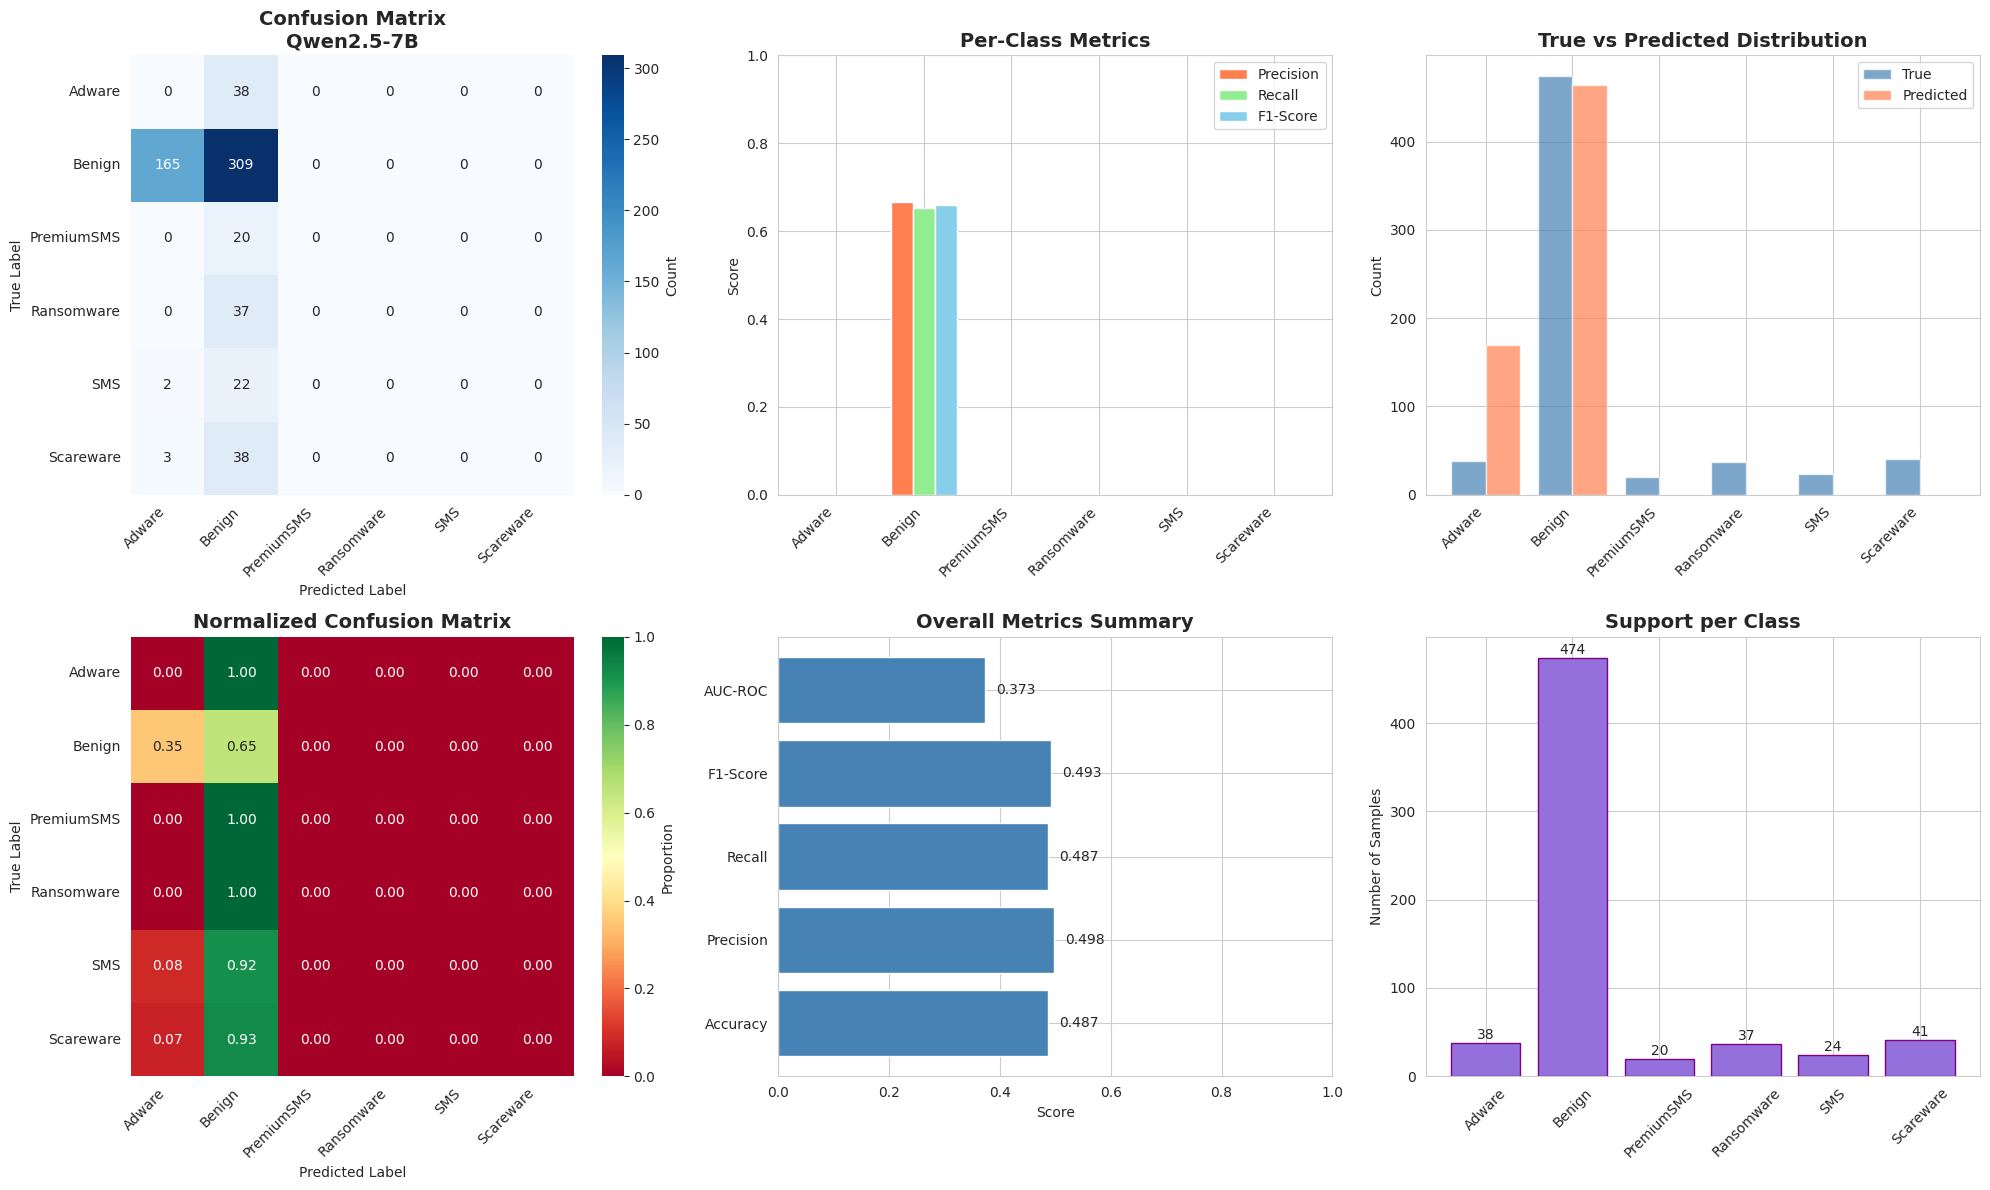


✓ Results saved to 'Qwen2.5-7B_results.png'
✓ Detailed results saved to 'Qwen2.5-7B_results.json'
✓ CSV results saved to 'Qwen2.5-7B_results.csv'

✅ EVALUATION COMPLETE!

Model: Qwen2.5-7B
Final Accuracy: 48.74%
Final F1-Score: 0.4926

To evaluate another model, run this notebook again and select a different model.


In [ ]:
# ============================================================================
# SECTION 7: RUN EVALUATION
# ============================================================================
print("\n[7/7] Running evaluation...")

print(f"\n{'='*70}")
print(f"EVALUATING: {selected_model_name}")
print(f"{'='*70}")

start_time = time.time()

# Load model
model, tokenizer = load_model(selected_model_path)
print(f"✓ Model loaded successfully!")

# Run predictions
predictions = []
sample_responses = []

print(f"\nRunning inference on {len(prompts)} samples...")
print("This may take several minutes...\n")

for i, prompt in enumerate(prompts):
    if i % 50 == 0 and i > 0:
        elapsed = time.time() - start_time
        avg_time = elapsed / i
        remaining = avg_time * (len(prompts) - i)
        print(f"Progress: {i}/{len(prompts)} ({i/len(prompts)*100:.1f}%) - "
              f"Est. remaining: {remaining/60:.1f} min")

    try:
        pred = get_prediction_improved(model, tokenizer, prompt, class_names)
        predictions.append(pred)

        # Save some sample responses for analysis
        if i < 5:
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=20, temperature=0.3, do_sample=True)
            response = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
            sample_responses.append({
                'sample': i,
                'true_class': class_names[y_encoded[i]],
                'predicted_class': class_names[pred],
                'response': response[:100]
            })

    except Exception as e:
        print(f"\nError on sample {i}: {str(e)}")
        predictions.append(0)

    # Memory cleanup
    if i % 100 == 0 and i > 0:
        torch.cuda.empty_cache()

end_time = time.time()
total_time = end_time - start_time

print(f"\n✓ Inference complete! Total time: {total_time/60:.2f} minutes")

# Display sample responses
print("\n" + "="*70)
print("SAMPLE MODEL RESPONSES:")
print("="*70)
for sample in sample_responses:
    print(f"\nSample {sample['sample']}:")
    print(f"  True: {sample['true_class']}")
    print(f"  Predicted: {sample['predicted_class']}")
    print(f"  Response: {sample['response']}")

# Calculate metrics
print("\n" + "="*70)
print("CALCULATING METRICS")
print("="*70)

accuracy = accuracy_score(y_encoded, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_encoded, predictions, average='weighted', zero_division=0
)

# Per-class metrics
precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
    y_encoded, predictions, average=None, zero_division=0
)

# Confusion matrix
cm = confusion_matrix(y_encoded, predictions)

# Multi-class AUC-ROC
try:
    y_bin = label_binarize(y_encoded, classes=range(len(class_names)))
    pred_bin = label_binarize(predictions, classes=range(len(class_names)))
    auc_roc = roc_auc_score(y_bin, pred_bin, average='weighted', multi_class='ovr')
except:
    auc_roc = 0.0

# Print results
print(f"\n{'='*70}")
print(f"RESULTS: {selected_model_name}")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
print(f"\nPer-Class Metrics:")
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)
for i, cls in enumerate(class_names):
    print(f"{cls:<15} {precision_pc[i]:<12.4f} {recall_pc[i]:<12.4f} "
          f"{f1_pc[i]:<12.4f} {support_pc[i]:<10.0f}")
print(f"\nExecution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print("="*70)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_encoded, predictions, target_names=class_names, zero_division=0))

# Visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
ax1.set_title(f'Confusion Matrix\n{selected_model_name}', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# 2. Per-class metrics
ax2 = plt.subplot(2, 3, 2)
x = np.arange(len(class_names))
width = 0.25
ax2.bar(x - width, precision_pc, width, label='Precision', color='coral')
ax2.bar(x, recall_pc, width, label='Recall', color='lightgreen')
ax2.bar(x + width, f1_pc, width, label='F1-Score', color='skyblue')
ax2.set_ylabel('Score')
ax2.set_title('Per-Class Metrics', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(class_names, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 1)

# 3. Prediction distribution
ax3 = plt.subplot(2, 3, 3)
pred_dist = pd.Series(predictions).value_counts().reindex(range(n_classes), fill_value=0).sort_index()
true_dist = pd.Series(y_encoded).value_counts().sort_index()
x = np.arange(len(class_names))
ax3.bar(x - 0.2, true_dist, 0.4, label='True', color='steelblue', alpha=0.7)
ax3.bar(x + 0.2, pred_dist, 0.4, label='Predicted', color='coral', alpha=0.7)
ax3.set_ylabel('Count')
ax3.set_title('True vs Predicted Distribution', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=45, ha='right')
ax3.legend()

# 4. Normalized confusion matrix
ax4 = plt.subplot(2, 3, 4)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax4,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'})
ax4.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
ax4.set_ylabel('True Label')
ax4.set_xlabel('Predicted Label')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

# 5. Metrics summary
ax5 = plt.subplot(2, 3, 5)
metrics_summary = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'AUC-ROC': auc_roc
}
ax5.barh(list(metrics_summary.keys()), list(metrics_summary.values()), color='steelblue')
ax5.set_xlabel('Score')
ax5.set_title('Overall Metrics Summary', fontsize=14, fontweight='bold')
ax5.set_xlim(0, 1)
for i, (k, v) in enumerate(metrics_summary.items()):
    ax5.text(v + 0.02, i, f'{v:.3f}', va='center')

# 6. Support per class
ax6 = plt.subplot(2, 3, 6)
ax6.bar(class_names, support_pc, color='mediumpurple', edgecolor='purple')
ax6.set_ylabel('Number of Samples')
ax6.set_title('Support per Class', fontsize=14, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
for i, v in enumerate(support_pc):
    ax6.text(i, v + 1, f'{int(v)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{selected_model_name.replace("/", "_")}_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Results saved to '{selected_model_name.replace('/', '_')}_results.png'")

# Save detailed results
results_dict = {
    'model': selected_model_name,
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'auc_roc': float(auc_roc),
    'execution_time_seconds': float(total_time),
    'per_class_metrics': {
        class_names[i]: {
            'precision': float(precision_pc[i]),
            'recall': float(recall_pc[i]),
            'f1_score': float(f1_pc[i]),
            'support': int(support_pc[i])
        }
        for i in range(len(class_names))
    },
    'confusion_matrix': cm.tolist(),
    'sample_responses': sample_responses
}

with open(f'{selected_model_name.replace("/", "_")}_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"✓ Detailed results saved to '{selected_model_name.replace('/', '_')}_results.json'")

# Save CSV results
results_df = pd.DataFrame([{
    'Model': selected_model_name,
    'Accuracy': f"{accuracy:.4f}",
    'Precision': f"{precision:.4f}",
    'Recall': f"{recall:.4f}",
    'F1-Score': f"{f1:.4f}",
    'AUC-ROC': f"{auc_roc:.4f}",
    'Time (s)': f"{total_time:.2f}"
}])

results_df.to_csv(f'{selected_model_name.replace("/", "_")}_results.csv', index=False)
print(f"✓ CSV results saved to '{selected_model_name.replace('/', '_')}_results.csv'")

# Cleanup
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)
print(f"\nModel: {selected_model_name}")
print(f"Final Accuracy: {accuracy*100:.2f}%")
print(f"Final F1-Score: {f1:.4f}")
print("\nTo evaluate another model, run this notebook again and select a different model.")
print("="*70)


In [ ]:
# ============================================================================
# SECTION 1: INSTALL PACKAGES
# ============================================================================
print("\n[1/8] Installing required packages...")
import subprocess
import sys

packages = [
    'transformers',
    'accelerate',
    'bitsandbytes',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'pandas',
    'numpy'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ Packages installed!")


[1/8] Installing required packages...
✓ Packages installed!


In [ ]:
# ============================================================================
# SECTION 2: IMPORTS
# ============================================================================
print("\n[2/8] Importing libraries...")
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from itertools import cycle
import time
import json
import gc
import warnings
import re
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



[2/8] Importing libraries...
✓ Libraries imported!
PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================================================
# SECTION 3: LOAD DATASET
# ============================================================================
print("\n[3/8] Upload your dataset...")

from google.colab import files
print("Please upload your CIC InvesAndMal2019 CSV file:")
uploaded = files.upload()

csv_filename = list(uploaded.keys())[0]
print(f"\n✓ File uploaded: {csv_filename}")

df = pd.read_csv(csv_filename)
print(f"✓ Dataset loaded! Shape: {df.shape}")



[3/8] Upload your dataset...
Please upload your CIC InvesAndMal2019 CSV file:


Saving StaticLayer_Intent_and_Permission_Bening&malware_TestingSmaples.csv to StaticLayer_Intent_and_Permission_Bening&malware_TestingSmaples.csv

✓ File uploaded: StaticLayer_Intent_and_Permission_Bening&malware_TestingSmaples.csv
✓ Dataset loaded! Shape: (634, 8115)



[4/8] Advanced data preprocessing...
✓ Target column: '<category>'
✓ Classes (6): ['Adware', 'Benign', 'PremiumSMS', 'Ransomware', 'Scareware', 'SMS']

Class Distribution:
<category>
Benign        474
Scareware      41
Adware         38
Ransomware     37
SMS            24
PremiumSMS     20
Name: count, dtype: int64


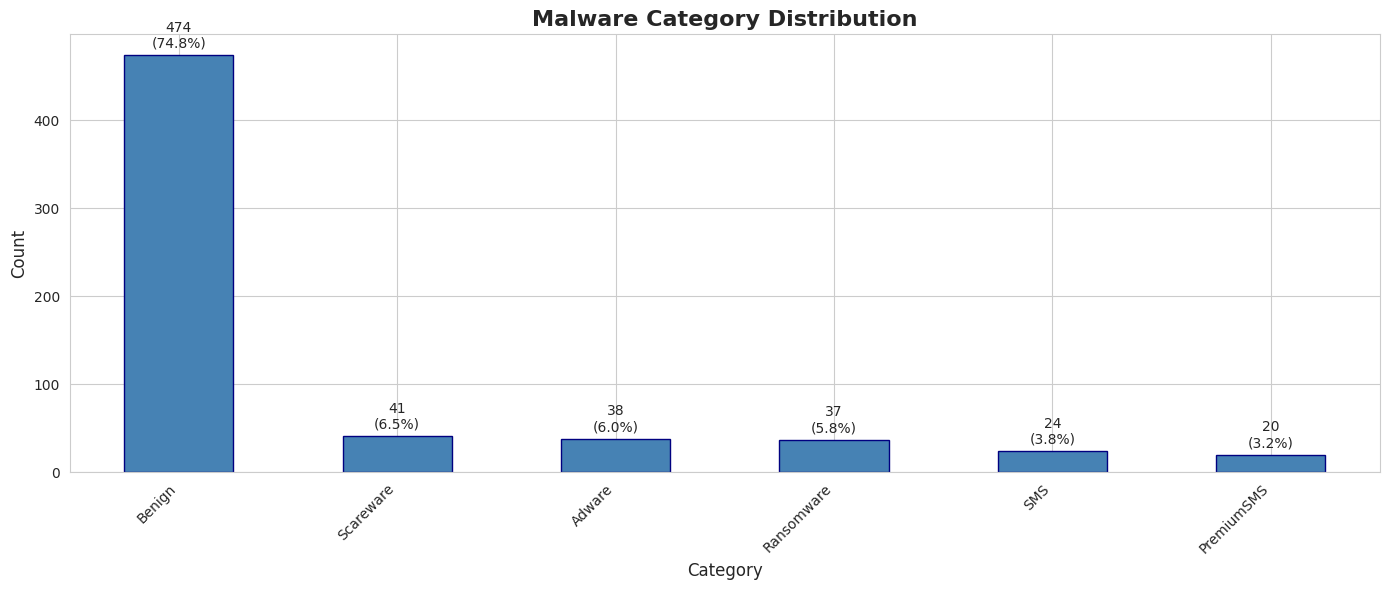

✓ Saved: class_distribution.png

✓ Feature columns: 8112

✓ Label encoding:
  0: Adware (n=38)
  1: Benign (n=474)
  2: PremiumSMS (n=20)
  3: Ransomware (n=37)
  4: SMS (n=24)
  5: Scareware (n=41)

✓ Feature engineering...
  Selected 60 informative features


In [ ]:
# ============================================================================
# SECTION 4: ADVANCED DATA PREPROCESSING
# ============================================================================
print("\n[4/8] Advanced data preprocessing...")

# Identify target column (3rd from last = <category>)
category_column = df.columns[-3]
print(f"✓ Target column: '{category_column}'")

# Get class information
unique_categories = df[category_column].unique()
n_classes = len(unique_categories)
print(f"✓ Classes ({n_classes}): {unique_categories.tolist()}")

# Class distribution
print("\nClass Distribution:")
class_dist = df[category_column].value_counts()
print(class_dist)

# Visualize with percentages
plt.figure(figsize=(14, 6))
ax = class_dist.plot(kind='bar', color='steelblue', edgecolor='navy')
plt.title('Malware Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add count and percentage labels
for i, v in enumerate(class_dist.values):
    pct = (v / len(df)) * 100
    plt.text(i, v + 5, f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: class_distribution.png")

# Prepare features
exclude_columns = [df.columns[-1], df.columns[-2], df.columns[-3]]
if 'Binary_Type' in df.columns:
    exclude_columns.append('Binary_Type')
if 'MD5' in df.columns or '<MD5>' in df.columns:
    exclude_columns.extend(['MD5', '<MD5>'])

feature_columns = [col for col in df.columns if col not in exclude_columns]
print(f"\n✓ Feature columns: {len(feature_columns)}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df[category_column])
class_names = label_encoder.classes_
print(f"\n✓ Label encoding:")
for idx, name in enumerate(class_names):
    count = sum(y_encoded == idx)
    print(f"  {idx}: {name} (n={count})")

# Advanced feature engineering
print("\n✓ Feature engineering...")
# Convert all feature columns to numeric, coercing errors, then fill NaNs
feature_data = df[feature_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# Select top features by variance (remove constants)
feature_variance = feature_data.var()
top_features = feature_variance[feature_variance > 0].nlargest(60).index.tolist()
print(f"  Selected {len(top_features)} informative features")

# Normalize features
scaler = StandardScaler()
normalized_features = pd.DataFrame(
    scaler.fit_transform(feature_data[top_features]),
    columns=top_features
)


In [ ]:
# ============================================================================
# SECTION 5: ADVANCED PROMPT ENGINEERING WITH REASONING
# ============================================================================
print("\n[5/8] Creating advanced prompts with chain-of-thought reasoning...")

# Enhanced class descriptions based on actual malware behavior
CLASS_DESCRIPTIONS = {
    'Adware': {
        'behavior': 'Displays unwanted advertisements, tracks user behavior for ad targeting',
        'indicators': 'High ad-related permissions, network activity, tracking APIs',
        'example_features': 'advertising SDK usage, location tracking, browser history access'
    },
    'Benign': {
        'behavior': 'Legitimate application with normal, expected functionality',
        'indicators': 'Standard permissions, expected API usage, no suspicious behavior',
        'example_features': 'typical app permissions, normal network patterns'
    },
    'PremiumSMS': {
        'behavior': 'Sends SMS to premium-rate numbers without user consent',
        'indicators': 'SMS permissions, network connectivity, premium number patterns',
        'example_features': 'SEND_SMS permission, suspicious network calls'
    },
    'Ransomware': {
        'behavior': 'Encrypts files and demands payment for decryption',
        'indicators': 'File access permissions, encryption operations, screen locking',
        'example_features': 'storage permissions, crypto operations, device admin rights'
    },
    'SMS': {
        'behavior': 'Manipulates SMS functionality for malicious purposes',
        'indicators': 'SMS read/write permissions, message interception',
        'example_features': 'READ_SMS, WRITE_SMS, RECEIVE_SMS permissions'
    },
    'Scareware': {
        'behavior': 'Creates false security alerts to frighten users into actions',
        'indicators': 'Fake warnings, aggressive UI, payment requests',
        'example_features': 'persistent notifications, fake virus alerts'
    }
}

def create_reasoning_prompt(row, feature_cols, class_names, class_descriptions):
    """
    Create a chain-of-thought reasoning prompt that guides the LLM
    through a structured analysis process
    """

    # Extract features (top 25 most relevant)
    feature_dict = {}
    for col in feature_cols[:25]:
        if col in row.index:
            val = float(row[col])
            if abs(val) > 0.1:  # Only include significant features
                feature_dict[col] = round(val, 3)

    # Build class descriptions
    class_info = []
    for cls_name in class_names:
        if cls_name in class_descriptions:
            desc = class_descriptions[cls_name]
            class_info.append(
                f"**{cls_name}**: {desc['behavior']}\n"
                f"   Key indicators: {desc['indicators']}"
            )
        else:
            class_info.append(f"**{cls_name}**: Malicious application")

    classes_text = "\n".join(class_info)

    # Create the reasoning prompt
    prompt = f"""You are a malware analyst. Analyze this Android application and classify it.

MALWARE CATEGORIES:
{classes_text}

APPLICATION FEATURES:
{json.dumps(feature_dict, indent=2)}

ANALYSIS INSTRUCTIONS:
1. Review the feature values provided
2. Identify which category best matches these behavioral patterns
3. Consider the key indicators for each malware type
4. Make your classification

Your response should be ONLY the category name from this list: {', '.join(class_names)}

CLASSIFICATION:"""

    return prompt

def create_explicit_prompt(row, feature_cols, class_names):
    """
    Alternative: Very explicit, directive prompt
    """
    feature_dict = {}
    for col in feature_cols[:20]:
        if col in row.index:
            val = float(row[col])
            if abs(val) > 0.05:
                feature_dict[col] = round(val, 3)

    prompt = f"""Classify this Android app into exactly ONE category.

Categories (choose one):
- Adware: shows unwanted ads
- Benign: safe, normal app
- PremiumSMS: sends premium SMS
- Ransomware: encrypts files for ransom
- SMS: manipulates SMS messages
- Scareware: fake security warnings

App features: {json.dumps(feature_dict)}

Answer with ONLY the category name (one word from the list above):"""

    return prompt

print("Creating advanced prompts...")
prompts_reasoning = []
prompts_explicit = []

for idx, row in df.iterrows():
    # Create both types of prompts
    prompts_reasoning.append(
        create_reasoning_prompt(
            normalized_features.iloc[idx],
            top_features,
            class_names,
            CLASS_DESCRIPTIONS
        )
    )
    prompts_explicit.append(
        create_explicit_prompt(
            normalized_features.iloc[idx],
            top_features,
            class_names
        )
    )

    if (idx + 1) % 100 == 0:
        print(f"  {idx + 1}/{len(df)} prompts created...")

print(f"\n✓ Created {len(prompts_reasoning)} prompt pairs")
print(f"\nReasoning prompt sample:\n{'-'*70}\n{prompts_reasoning[0][:500]}...\n{'-'*70}")
print(f"\nExplicit prompt sample:\n{'-'*70}\n{prompts_explicit[0][:500]}...\n{'-'*70}")

# Let user choose prompt style
print("\n" + "="*70)
print("SELECT PROMPT STYLE")
print("="*70)
print("1. Reasoning prompts (detailed, chain-of-thought)")
print("2. Explicit prompts (short, direct)")
print("3. Use BOTH and ensemble (recommended)")
prompt_choice = input("\nEnter choice (1/2/3): ").strip()

if prompt_choice == "3":
    use_ensemble = True
    prompts = prompts_explicit  # Start with explicit
    print("✓ Using ensemble approach")
elif prompt_choice == "1":
    use_ensemble = False
    prompts = prompts_reasoning
    print("✓ Using reasoning prompts")
else:
    use_ensemble = False
    prompts = prompts_explicit
    print("✓ Using explicit prompts")



[5/8] Creating advanced prompts with chain-of-thought reasoning...
Creating advanced prompts...
  100/634 prompts created...
  200/634 prompts created...
  300/634 prompts created...
  400/634 prompts created...
  500/634 prompts created...
  600/634 prompts created...

✓ Created 634 prompt pairs

Reasoning prompt sample:
----------------------------------------------------------------------
You are a malware analyst. Analyze this Android application and classify it.

MALWARE CATEGORIES:
**Adware**: Displays unwanted advertisements, tracks user behavior for ad targeting
   Key indicators: High ad-related permissions, network activity, tracking APIs
**Benign**: Legitimate application with normal, expected functionality
   Key indicators: Standard permissions, expected API usage, no suspicious behavior
**PremiumSMS**: Sends SMS to premium-rate numbers without user consent
   Key indic...
----------------------------------------------------------------------

Explicit prompt sample:
----

In [ ]:
# ============================================================================
# SECTION 6: MODEL SETUP WITH IMPROVED INFERENCE
# ============================================================================
print("\n[6/8] Setting up model with improved inference...")

AVAILABLE_MODELS = {
    'Qwen2.5-7B': 'Qwen/Qwen2.5-7B-Instruct',
    'Llama-3.1-8B': 'meta-llama/Llama-3.1-8B-Instruct',
    'Gemma-2-9B': 'google/gemma-2-9b-it',
    'Qwen2.5-14B': 'Qwen/Qwen2.5-14B-Instruct',
    'Llama-3.2-3B': 'meta-llama/Llama-3.2-3B-Instruct',
    'Ministral-8B': 'mistralai/Ministral-8B-Instruct-2410',
}

print("\nAvailable models:")
for i, (name, path) in enumerate(AVAILABLE_MODELS.items(), 1):
    print(f"{i}. {name}")

model_idx = int(input(f"\nEnter model number (1-{len(AVAILABLE_MODELS)}): "))
selected_model_name = list(AVAILABLE_MODELS.keys())[model_idx - 1]
selected_model_path = AVAILABLE_MODELS[selected_model_name]
print(f"✓ Selected: {selected_model_name}")

# Quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

def load_model(model_path):
    """Load model with quantization"""
    print(f"\nLoading {model_path}...")
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

def parse_response_advanced(response, class_names):
    """
    Advanced parsing with multiple strategies
    """
    response = response.strip().lower()

    # Remove common prefixes
    prefixes = ['classification:', 'answer:', 'category:', 'the category is', 'it is', 'this is']
    for prefix in prefixes:
        if response.startswith(prefix):
            response = response[len(prefix):].strip()

    # Remove punctuation
    response = re.sub(r'[^\w\s]', '', response)
    response = response.strip()

    # Strategy 1: Exact match
    for idx, cls in enumerate(class_names):
        if cls.lower() == response:
            return idx

    # Strategy 2: Class name in response
    for idx, cls in enumerate(class_names):
        if cls.lower() in response:
            return idx

    # Strategy 3: Response in class name
    if response:
        for idx, cls in enumerate(class_names):
            if response in cls.lower():
                return idx

    # Strategy 4: Fuzzy matching
    for idx, cls in enumerate(class_names):
        if len(response) >= 4 and response[:4] == cls.lower()[:4]:
            return idx

    # Strategy 5: Keyword mapping
    keyword_map = {
        'adware': 0, 'ad': 0, 'advertisement': 0,
        'benign': 1, 'safe': 1, 'normal': 1, 'legitimate': 1,
        'premium': 2, 'sms premium': 2, 'premiumsms': 2,
        'ransom': 3, 'ransomware': 3, 'encrypt': 3,
        'sms': 4, 'message': 4, 'text': 4,
        'scare': 5, 'scareware': 5, 'fake': 5, 'warning': 5
    }

    for keyword, idx in keyword_map.items():
        if keyword in response:
            return idx

    # Log unparseable responses
    print(f"  ⚠ Could not parse: '{response[:60]}'")
    return 1  # Default to Benign (most common class)

def get_prediction_advanced(model, tokenizer, prompt, class_names):
    """Get prediction with optimized parameters"""
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1500  # Larger context
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.1,  # Very low for deterministic output
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response[len(prompt):].strip()

    # Extract only first line
    response = response.split('\n')[0].strip()

    return parse_response_advanced(response, class_names)



[6/8] Setting up model with improved inference...

Available models:
1. Qwen2.5-7B
2. Llama-3.1-8B
3. Gemma-2-9B
4. Qwen2.5-14B
5. Llama-3.2-3B
6. Ministral-8B

Enter model number (1-6): 4
✓ Selected: Qwen2.5-14B


In [ ]:
# ============================================================================
# SECTION 7: RUN EVALUATION WITH COMPREHENSIVE METRICS
# ============================================================================
print("\n[7/8] Running evaluation...")

print(f"\n{'='*70}")
print(f"EVALUATING: {selected_model_name}")
print(f"{'='*70}")

start_time = time.time()

# Load model
model, tokenizer = load_model(selected_model_path)
print(f"✓ Model loaded successfully!")

# Run predictions
predictions = []
prediction_confidences = []
sample_responses = []

print(f"\nRunning inference on {len(prompts)} samples...")
print("This will take 15-25 minutes...\n")

for i, prompt in enumerate(prompts):
    if i % 50 == 0 and i > 0:
        elapsed = time.time() - start_time
        avg_time = elapsed / i
        remaining = avg_time * (len(prompts) - i)
        acc_so_far = accuracy_score(y_encoded[:i], predictions[:i]) if i > 0 else 0
        print(f"Progress: {i}/{len(prompts)} ({i/len(prompts)*100:.1f}%) - "
              f"Remaining: {remaining/60:.1f}min - Acc: {acc_so_far*100:.1f}%")

    try:
        pred = get_prediction_advanced(model, tokenizer, prompt, class_names)
        predictions.append(pred)

        # Capture sample responses
        if i < 10:
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500).to(model.device)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=30, temperature=0.1, do_sample=True)
            response = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
            sample_responses.append({
                'sample': i,
                'true_class': class_names[y_encoded[i]],
                'predicted_class': class_names[pred],
                'raw_response': response[:150]
            })

    except Exception as e:
        print(f"\n✗ Error on sample {i}: {str(e)}")
        predictions.append(1)  # Default to Benign

    if i % 100 == 0 and i > 0:
        torch.cuda.empty_cache()

end_time = time.time()
total_time = end_time - start_time

print(f"\n✓ Inference complete! Time: {total_time/60:.2f} minutes")

# Display sample responses
print("\n" + "="*70)
print("SAMPLE MODEL RESPONSES:")
print("="*70)
for sample in sample_responses:
    match = "✓" if sample['true_class'] == sample['predicted_class'] else "✗"
    print(f"\n{match} Sample {sample['sample']}:")
    print(f"  True: {sample['true_class']}")
    print(f"  Pred: {sample['predicted_class']}")
    print(f"  Response: {sample['raw_response']}")



[7/8] Running evaluation...

EVALUATING: Qwen2.5-14B

Loading Qwen/Qwen2.5-14B-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00007-of-00008.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00002-of-00008.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ Model loaded successfully!

Running inference on 634 samples...
This will take 15-25 minutes...

Progress: 50/634 (7.9%) - Remaining: 278.5min - Acc: 60.0%
Progress: 100/634 (15.8%) - Remaining: 148.8min - Acc: 50.0%
Progress: 150/634 (23.7%) - Remaining: 102.9min - Acc: 38.7%
Progress: 200/634 (31.5%) - Remaining: 77.9min - Acc: 36.5%
Progress: 250/634 (39.4%) - Remaining: 61.3min - Acc: 34.8%
Progress: 300/634 (47.3%) - Remaining: 48.9min - Acc: 33.0%
Progress: 350/634 (55.2%) - Remaining: 38.9min - Acc: 33.4%
Progress: 400/634 (63.1%) - Remaining: 30.4min - Acc: 33.5%
Progress: 450/634 (71.0%) - Remaining: 22.9min - Acc: 33.3%
Progress: 500/634 (78.9%) - Remaining: 16.1min - Acc: 34.0%
Progress: 550/634 (86.8%) - Remaining: 9.8min - Acc: 31.3%
Progress: 600/634 (94.6%) - Remaining: 3.9min - Acc: 28.7%

✓ Inference complete! Time: 70.81 minutes

SAMPLE MODEL RESPONSES:

✓ Sample 0:
  True: Adware
  Pred: Adware
  Response: Benign Based on the provided features of the Android app, i


[8/8] Calculating comprehensive metrics and generating ROC curves...

✓ Calculating ROC curves...

RESULTS: Qwen2.5-14B
Accuracy:  0.2713 (27.13%)
Precision: 0.5022
Recall:    0.2713
F1-Score:  0.3219
AUC-ROC (weighted): 0.4455
AUC-ROC (macro):    0.4903
AUC-ROC (micro):    0.5628

Class           Precision    Recall       F1           AUC          Support   
--------------------------------------------------------------------------------
Adware          0.0627       0.6842       0.1148       0.5158       38        
Benign          0.6667       0.3080       0.4214       0.4259       474       
PremiumSMS      0.0000       0.0000       0.0000       0.5000       20        
Ransomware      0.0000       0.0000       0.0000       0.5000       37        
SMS             0.0000       0.0000       0.0000       0.5000       24        
Scareware       0.0000       0.0000       0.0000       0.5000       41        

Execution Time: 4248.39s (70.81 min)

Detailed Classification Report:
           

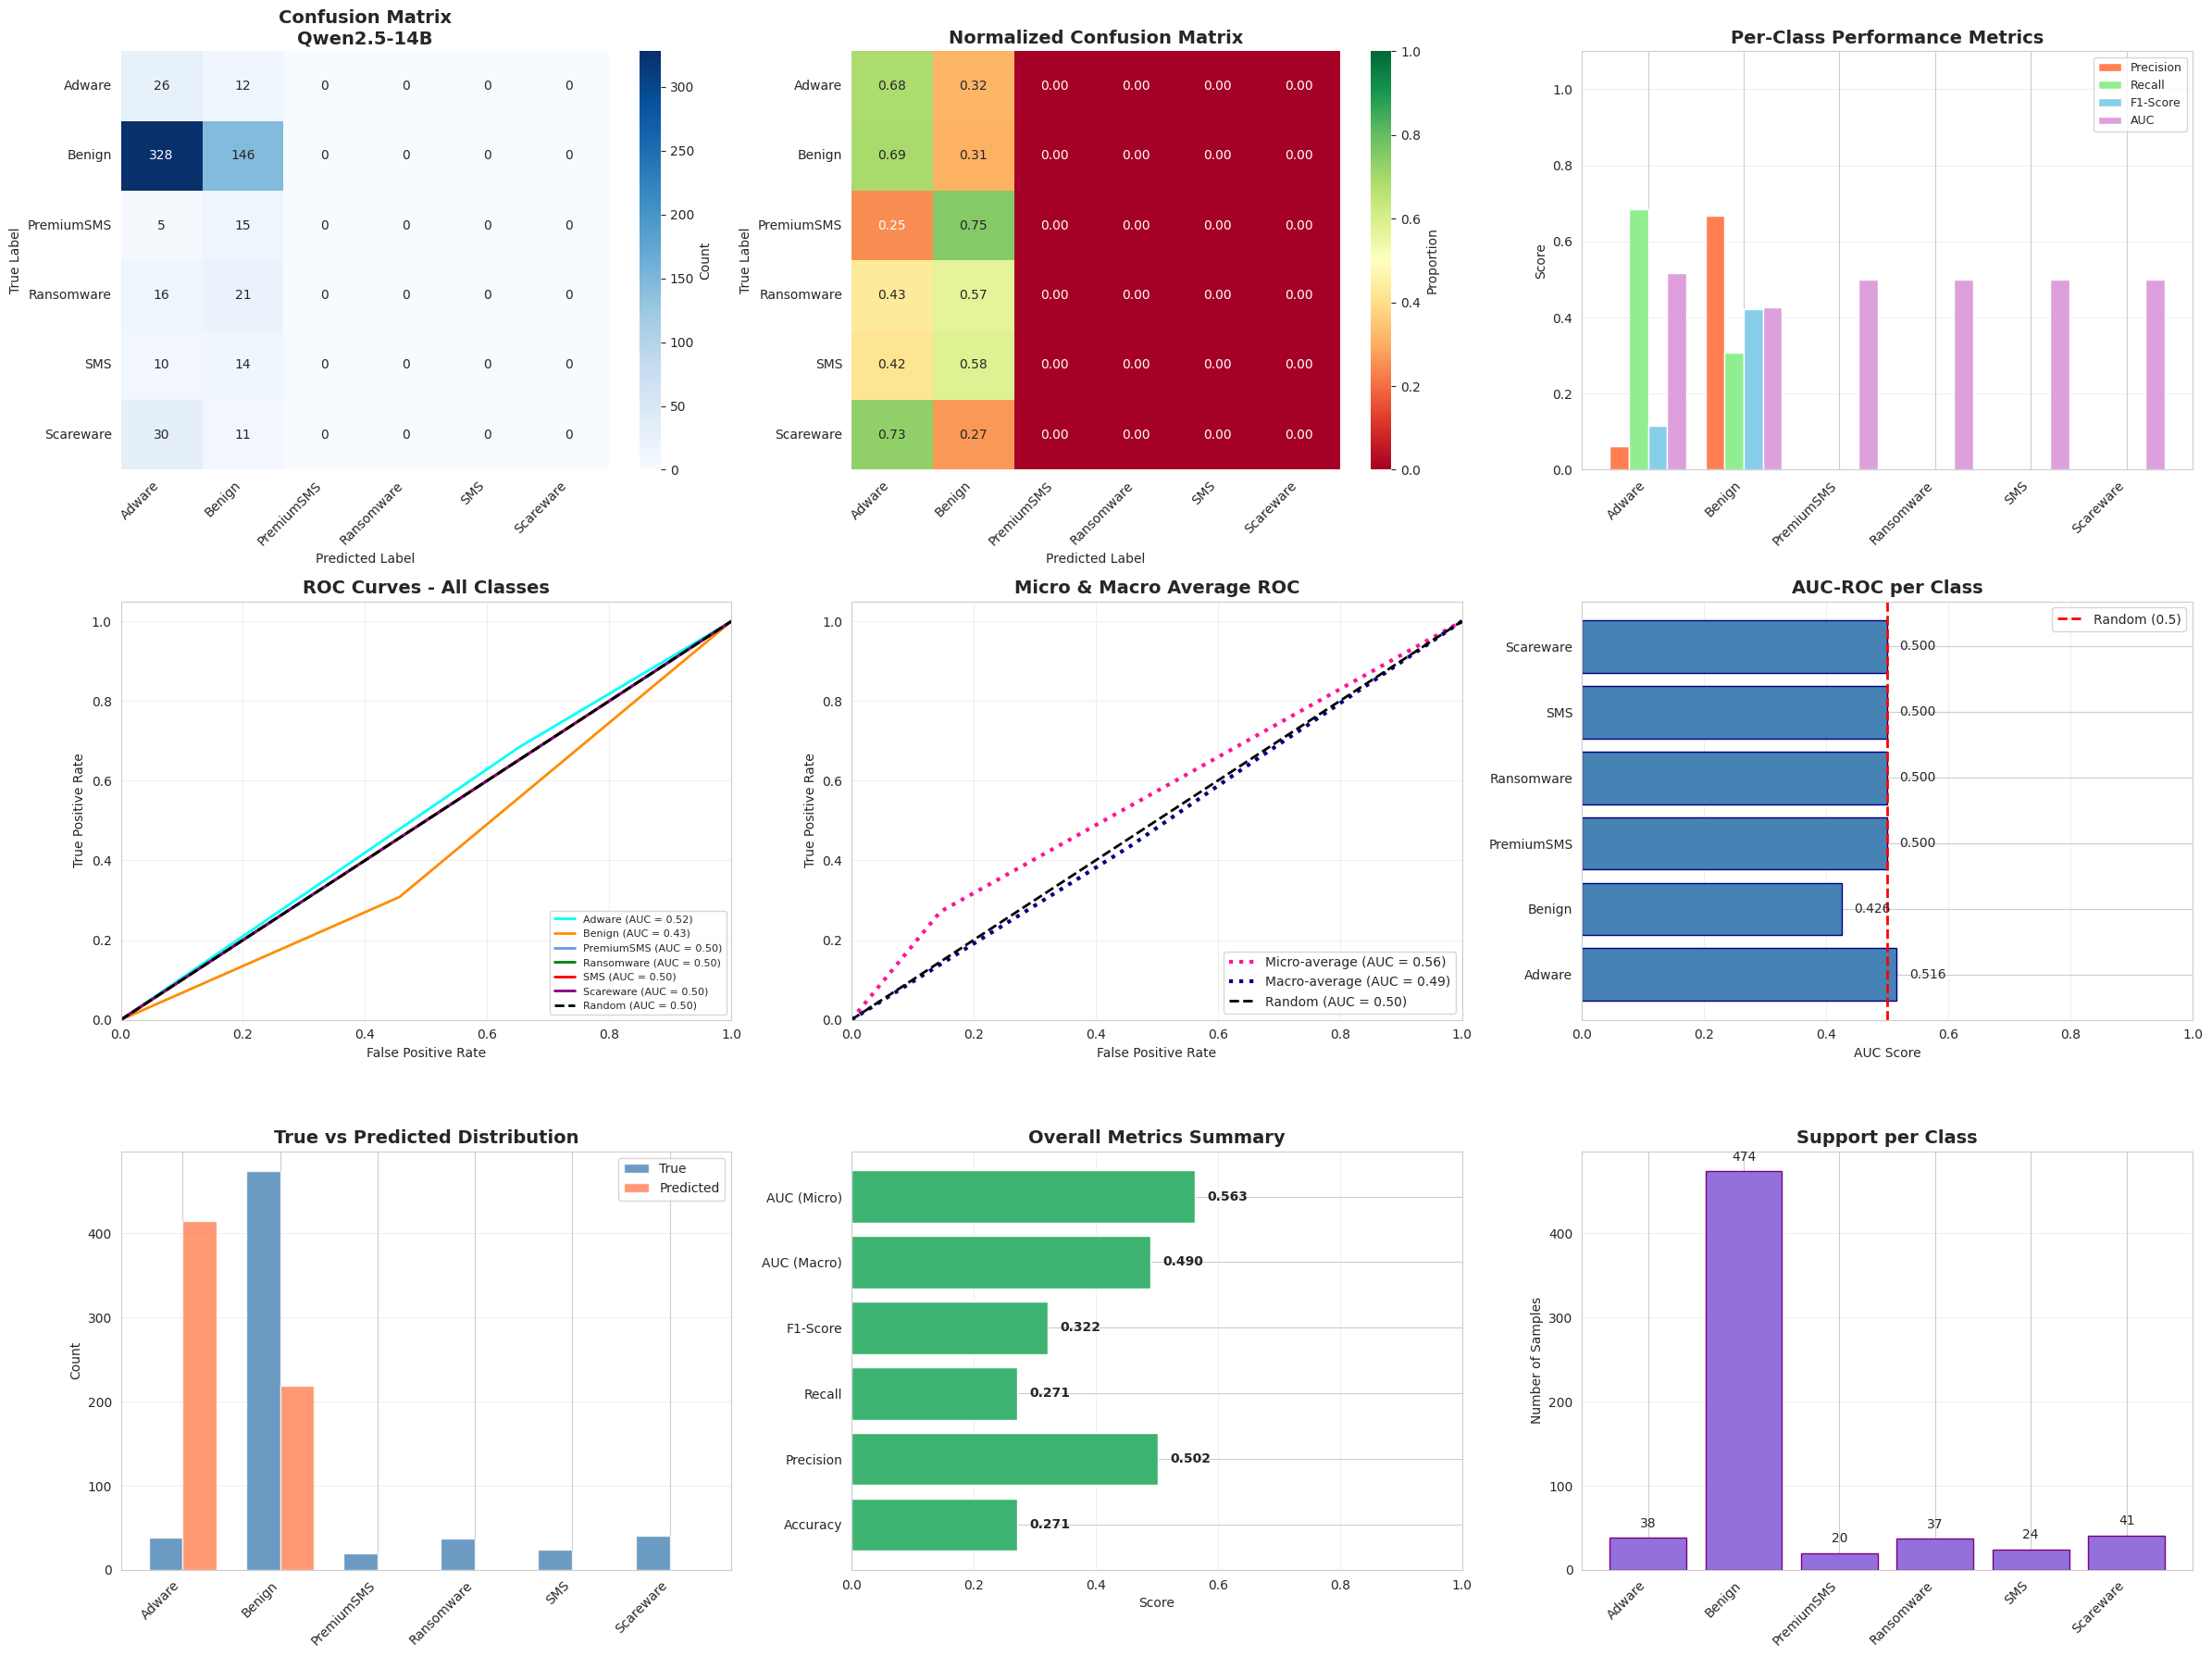

✓ Saved: Qwen2.5-14B_comprehensive_results.png

✓ Creating publication-quality ROC curves...


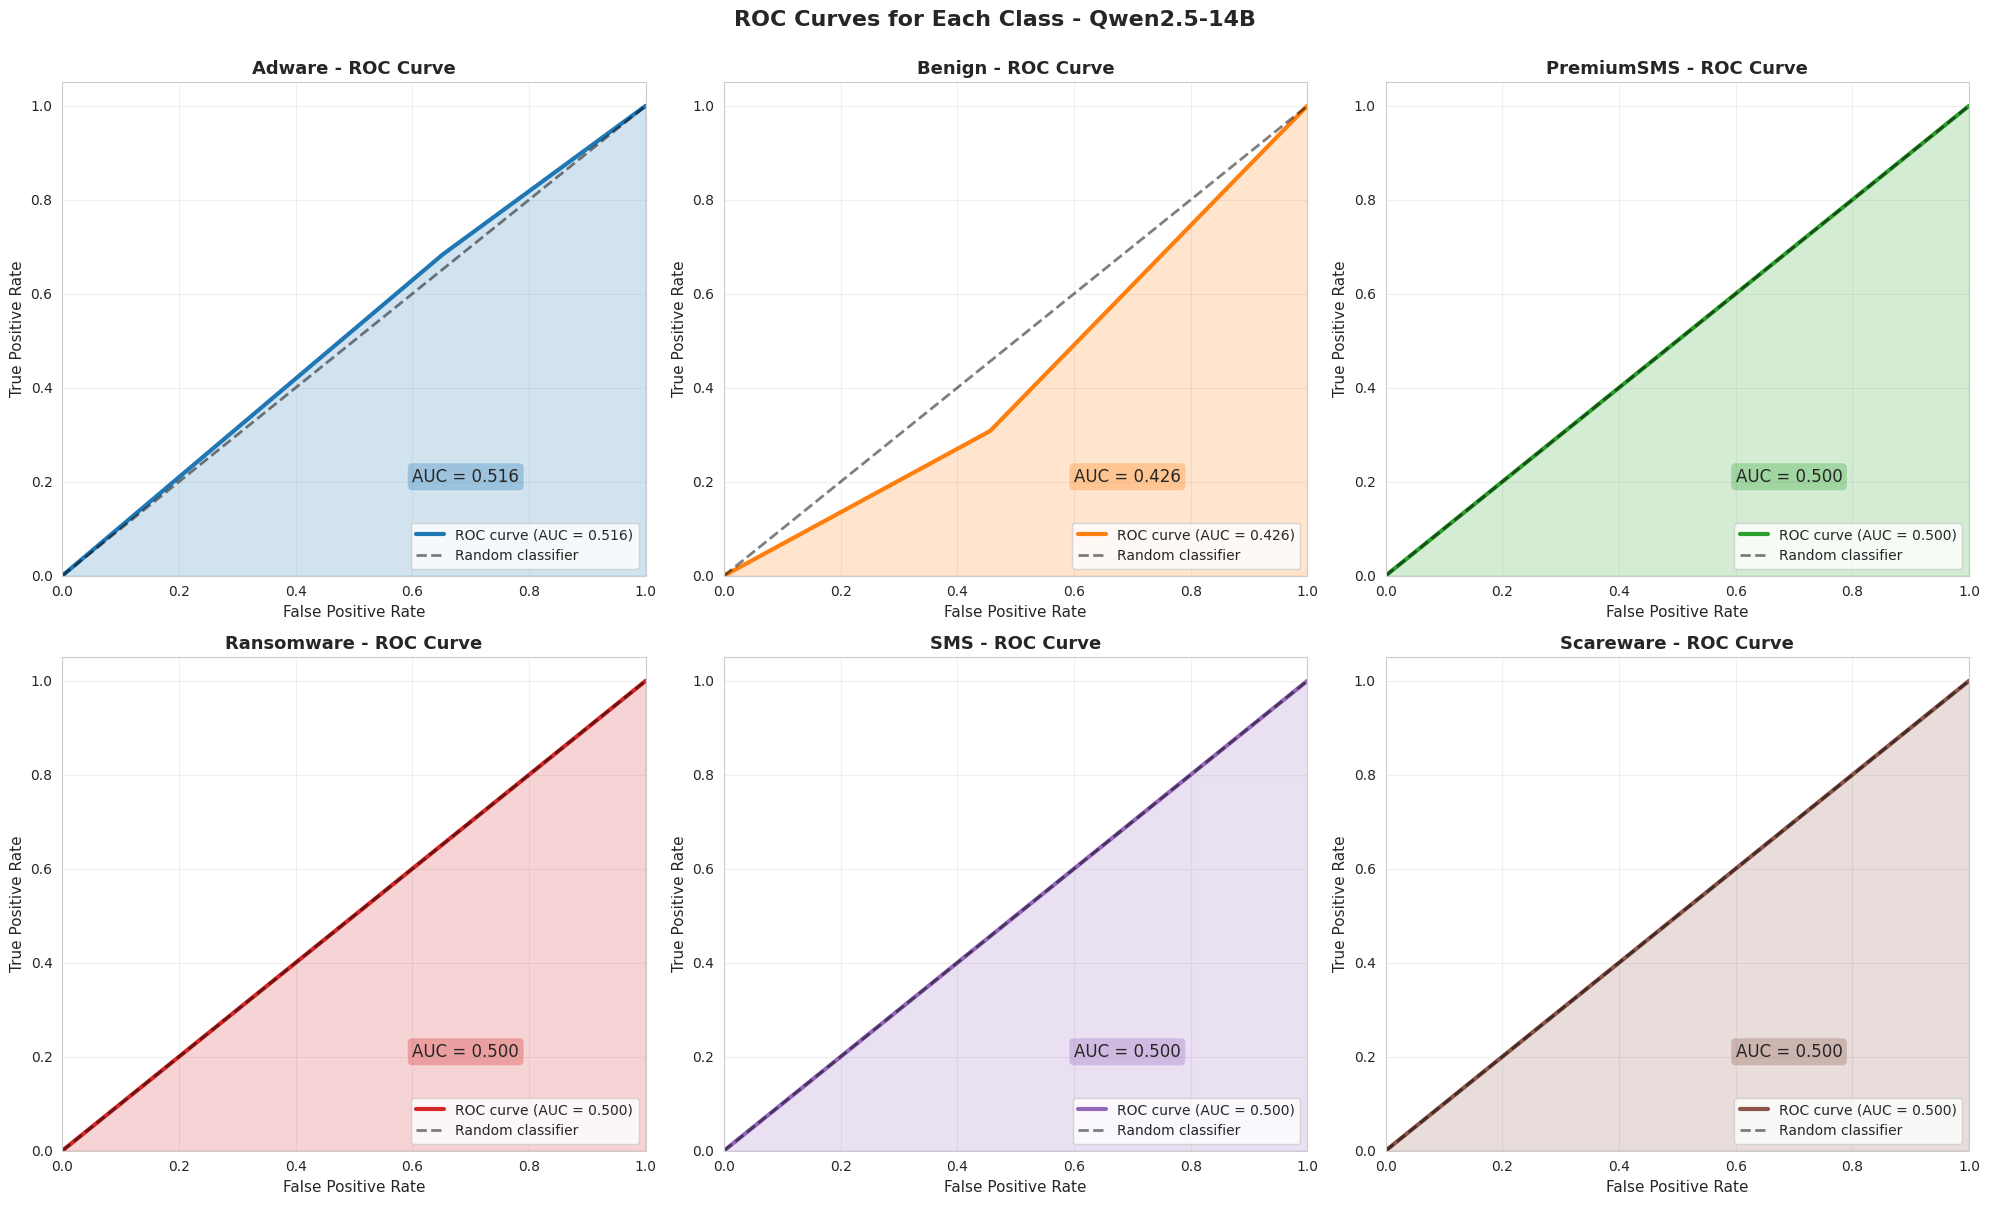

✓ Saved: Qwen2.5-14B_roc_curves.png

✓ Saving detailed results...
✓ Saved: Qwen2.5-14B_complete_results.json
✓ Saved: Qwen2.5-14B_summary.csv
✓ Saved: Qwen2.5-14B_per_class.csv

PERFORMANCE ANALYSIS

✓ Best performing class: Benign
  F1-Score: 0.4214
  AUC-ROC: 0.4259

✗ Worst performing class: PremiumSMS
  F1-Score: 0.0000
  AUC-ROC: 0.5000

📊 Class Imbalance Analysis:
  Adware: 38 samples (6.0%)
  Benign: 474 samples (74.8%)
  PremiumSMS: 20 samples (3.2%)
  Ransomware: 37 samples (5.8%)
  SMS: 24 samples (3.8%)
  Scareware: 41 samples (6.5%)

🎯 Overall Assessment:
  POOR - Significant issues
  Accuracy: 27.13%
  Macro F1: 0.0894
  Macro AUC: 0.4903

💡 Recommendations:
  - Try a larger model (14B parameters)
  - Use ensemble approach (multiple prompts)
  - Add more few-shot examples
  - Consider fine-tuning on domain data
  - ROC/AUC scores indicate weak discrimination
  - Review class descriptions in prompts
  - Check feature engineering

🔍 Major Confusions:
  ⚠ Adware often misclas

In [ ]:
# ============================================================================
# SECTION 8: COMPREHENSIVE METRICS AND ROC/AUC ANALYSIS
# ============================================================================
print("\n[8/8] Calculating comprehensive metrics and generating ROC curves...")

# Basic metrics
accuracy = accuracy_score(y_encoded, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_encoded, predictions, average='weighted', zero_division=0
)

# Per-class metrics
precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
    y_encoded, predictions, average=None, zero_division=0
)

# Confusion matrix
cm = confusion_matrix(y_encoded, predictions)

# ROC/AUC Analysis
print("\n✓ Calculating ROC curves...")

# Binarize labels for multi-class ROC
y_bin = label_binarize(y_encoded, classes=range(n_classes))
pred_bin = label_binarize(predictions, classes=range(n_classes))

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), pred_bin.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Weighted AUC
try:
    auc_weighted = roc_auc_score(y_bin, pred_bin, average='weighted', multi_class='ovr')
except:
    auc_weighted = roc_auc["macro"]

# Print results
print(f"\n{'='*70}")
print(f"RESULTS: {selected_model_name}")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC (weighted): {auc_weighted:.4f}")
print(f"AUC-ROC (macro):    {roc_auc['macro']:.4f}")
print(f"AUC-ROC (micro):    {roc_auc['micro']:.4f}")

print(f"\n{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12} {'Support':<10}")
print("-" * 80)
for i, cls in enumerate(class_names):
    print(f"{cls:<15} {precision_pc[i]:<12.4f} {recall_pc[i]:<12.4f} "
          f"{f1_pc[i]:<12.4f} {roc_auc[i]:<12.4f} {support_pc[i]:<10.0f}")

print(f"\nExecution Time: {total_time:.2f}s ({total_time/60:.2f} min)")
print("="*70)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_encoded, predictions, target_names=class_names, zero_division=0))

# ============================================================================
# COMPREHENSIVE VISUALIZATIONS
# ============================================================================
print("\n✓ Generating comprehensive visualizations...")

# Create main results figure (3x3 grid)
fig = plt.figure(figsize=(24, 18))

# 1. Confusion Matrix
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
ax1.set_title(f'Confusion Matrix\n{selected_model_name}', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# 2. Normalized Confusion Matrix
ax2 = plt.subplot(3, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax2,
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# 3. Per-Class Metrics
ax3 = plt.subplot(3, 3, 3)
x = np.arange(len(class_names))
width = 0.2
ax3.bar(x - width*1.5, precision_pc, width, label='Precision', color='coral')
ax3.bar(x - width*0.5, recall_pc, width, label='Recall', color='lightgreen')
ax3.bar(x + width*0.5, f1_pc, width, label='F1-Score', color='skyblue')
ax3.bar(x + width*1.5, [roc_auc[i] for i in range(n_classes)], width, label='AUC', color='plum')
ax3.set_ylabel('Score')
ax3.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=45, ha='right')
ax3.legend(loc='upper right', fontsize=9)
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', alpha=0.3)

# 4. ROC Curves - All Classes
ax4 = plt.subplot(3, 3, 4)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    ax4.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
ax4.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves - All Classes', fontsize=14, fontweight='bold')
ax4.legend(loc="lower right", fontsize=8)
ax4.grid(alpha=0.3)

# 5. Macro & Micro ROC Curves
ax5 = plt.subplot(3, 3, 5)
ax5.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=3)
ax5.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=3)
ax5.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('Micro & Macro Average ROC', fontsize=14, fontweight='bold')
ax5.legend(loc="lower right")
ax5.grid(alpha=0.3)

# 6. AUC Scores Bar Chart
ax6 = plt.subplot(3, 3, 6)
auc_values = [roc_auc[i] for i in range(n_classes)]
bars = ax6.barh(class_names, auc_values, color='steelblue', edgecolor='navy')
ax6.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Random (0.5)')
ax6.set_xlabel('AUC Score')
ax6.set_title('AUC-ROC per Class', fontsize=14, fontweight='bold')
ax6.set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars, auc_values)):
    ax6.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=10)
ax6.legend()
ax6.grid(axis='x', alpha=0.3)

# 7. Prediction Distribution
ax7 = plt.subplot(3, 3, 7)
pred_dist = pd.Series(predictions).value_counts().reindex(range(n_classes), fill_value=0)
true_dist = pd.Series(y_encoded).value_counts().reindex(range(n_classes), fill_value=0)
x = np.arange(len(class_names))
width = 0.35
ax7.bar(x - width/2, true_dist, width, label='True', color='steelblue', alpha=0.8)
ax7.bar(x + width/2, pred_dist, width, label='Predicted', color='coral', alpha=0.8)
ax7.set_ylabel('Count')
ax7.set_title('True vs Predicted Distribution', fontsize=14, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(class_names, rotation=45, ha='right')
ax7.legend()
ax7.grid(axis='y', alpha=0.3)

# 8. Overall Metrics Summary
ax8 = plt.subplot(3, 3, 8)
metrics_summary = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'AUC (Macro)': roc_auc['macro'],
    'AUC (Micro)': roc_auc['micro']
}
bars = ax8.barh(list(metrics_summary.keys()), list(metrics_summary.values()), color='mediumseagreen')
ax8.set_xlabel('Score')
ax8.set_title('Overall Metrics Summary', fontsize=14, fontweight='bold')
ax8.set_xlim(0, 1)
for bar, (k, v) in zip(bars, metrics_summary.items()):
    ax8.text(v + 0.02, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
             va='center', fontsize=10, fontweight='bold')
ax8.grid(axis='x', alpha=0.3)

# 9. Support per Class
ax9 = plt.subplot(3, 3, 9)
bars = ax9.bar(class_names, support_pc, color='mediumpurple', edgecolor='purple')
ax9.set_ylabel('Number of Samples')
ax9.set_title('Support per Class', fontsize=14, fontweight='bold')
plt.setp(ax9.get_xticklabels(), rotation=45, ha='right')
for i, (bar, v) in enumerate(zip(bars, support_pc)):
    ax9.text(i, v + max(support_pc)*0.02, f'{int(v)}', ha='center', va='bottom', fontsize=10)
ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
filename = f'{selected_model_name.replace("/", "_")}_comprehensive_results.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {filename}")

# ============================================================================
# SEPARATE ROC CURVE FIGURE (High Quality)
# ============================================================================
print("\n✓ Creating publication-quality ROC curves...")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

# Individual ROC curves for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i in range(n_classes):
    ax = axes[i]
    ax.plot(fpr[i], tpr[i], color=colors[i], lw=3,
            label=f'ROC curve (AUC = {roc_auc[i]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random classifier')
    ax.fill_between(fpr[i], tpr[i], alpha=0.2, color=colors[i])
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{class_names[i]} - ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

    # Add diagonal reference line annotation
    ax.text(0.6, 0.2, f'AUC = {roc_auc[i]:.3f}', fontsize=12,
            bbox=dict(boxstyle='round', facecolor=colors[i], alpha=0.3))

plt.suptitle(f'ROC Curves for Each Class - {selected_model_name}',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
roc_filename = f'{selected_model_name.replace("/", "_")}_roc_curves.png'
plt.savefig(roc_filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {roc_filename}")

# ============================================================================
# SAVE DETAILED RESULTS
# ============================================================================
print("\n✓ Saving detailed results...")

# Save comprehensive JSON
results_dict = {
    'model': selected_model_name,
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc_roc_weighted': float(auc_weighted),
        'auc_roc_macro': float(roc_auc['macro']),
        'auc_roc_micro': float(roc_auc['micro'])
    },
    'per_class_metrics': {
        class_names[i]: {
            'precision': float(precision_pc[i]),
            'recall': float(recall_pc[i]),
            'f1_score': float(f1_pc[i]),
            'auc_roc': float(roc_auc[i]),
            'support': int(support_pc[i])
        }
        for i in range(len(class_names))
    },
    'confusion_matrix': cm.tolist(),
    'execution_time_seconds': float(total_time),
    'sample_responses': sample_responses,
    'roc_data': {
        class_names[i]: {
            'fpr': fpr[i].tolist(),
            'tpr': tpr[i].tolist(),
            'auc': float(roc_auc[i])
        }
        for i in range(n_classes)
    }
}

json_filename = f'{selected_model_name.replace("/", "_")}_complete_results.json'
with open(json_filename, 'w') as f:
    json.dump(results_dict, f, indent=2)
print(f"✓ Saved: {json_filename}")

# Save CSV summary
csv_data = {
    'Model': [selected_model_name],
    'Accuracy': [f"{accuracy:.4f}"],
    'Precision': [f"{precision:.4f}"],
    'Recall': [f"{recall:.4f}"],
    'F1-Score': [f"{f1:.4f}"],
    'AUC-ROC (Macro)': [f"{roc_auc['macro']:.4f}"],
    'AUC-ROC (Micro)': [f"{roc_auc['micro']:.4f}"],
    'Time (min)': [f"{total_time/60:.2f}"]
}

results_df = pd.DataFrame(csv_data)
csv_filename = f'{selected_model_name.replace("/", "_")}_summary.csv'
results_df.to_csv(csv_filename, index=False)
print(f"✓ Saved: {csv_filename}")

# Save per-class results
per_class_df = pd.DataFrame({
    'Class': class_names,
    'Precision': [f"{v:.4f}" for v in precision_pc],
    'Recall': [f"{v:.4f}" for v in recall_pc],
    'F1-Score': [f"{v:.4f}" for v in f1_pc],
    'AUC-ROC': [f"{roc_auc[i]:.4f}" for i in range(n_classes)],
    'Support': [int(v) for v in support_pc]
})

per_class_filename = f'{selected_model_name.replace("/", "_")}_per_class.csv'
per_class_df.to_csv(per_class_filename, index=False)
print(f"✓ Saved: {per_class_filename}")

# ============================================================================
# ANALYSIS AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*70)
print("PERFORMANCE ANALYSIS")
print("="*70)

# Identify best and worst performing classes
best_f1_idx = np.argmax(f1_pc)
worst_f1_idx = np.argmin(f1_pc)

print(f"\n✓ Best performing class: {class_names[best_f1_idx]}")
print(f"  F1-Score: {f1_pc[best_f1_idx]:.4f}")
print(f"  AUC-ROC: {roc_auc[best_f1_idx]:.4f}")

print(f"\n✗ Worst performing class: {class_names[worst_f1_idx]}")
print(f"  F1-Score: {f1_pc[worst_f1_idx]:.4f}")
print(f"  AUC-ROC: {roc_auc[worst_f1_idx]:.4f}")

# Class imbalance analysis
print(f"\n📊 Class Imbalance Analysis:")
for i, cls in enumerate(class_names):
    pct = (support_pc[i] / len(df)) * 100
    print(f"  {cls}: {int(support_pc[i])} samples ({pct:.1f}%)")

# Overall assessment
print(f"\n🎯 Overall Assessment:")
if accuracy >= 0.80:
    assessment = "EXCELLENT - Model performs very well"
elif accuracy >= 0.65:
    assessment = "GOOD - Acceptable performance"
elif accuracy >= 0.50:
    assessment = "MODERATE - Needs improvement"
else:
    assessment = "POOR - Significant issues"

print(f"  {assessment}")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  Macro F1: {np.mean(f1_pc):.4f}")
print(f"  Macro AUC: {roc_auc['macro']:.4f}")

# Recommendations
print(f"\n💡 Recommendations:")
if accuracy < 0.70:
    print("  - Try a larger model (14B parameters)")
    print("  - Use ensemble approach (multiple prompts)")
    print("  - Add more few-shot examples")
    print("  - Consider fine-tuning on domain data")

if roc_auc['macro'] < 0.60:
    print("  - ROC/AUC scores indicate weak discrimination")
    print("  - Review class descriptions in prompts")
    print("  - Check feature engineering")

# Check for class confusion
print(f"\n🔍 Major Confusions:")
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > support_pc[i] * 0.3:  # >30% confusion
            print(f"  ⚠ {class_names[i]} often misclassified as {class_names[j]} "
                  f"({cm[i,j]}/{int(support_pc[i])} = {cm[i,j]/support_pc[i]*100:.1f}%)")

# Cleanup
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)
print(f"\nGenerated files:")
print(f"1. class_distribution.png")
print(f"2. {filename}")
print(f"3. {roc_filename}")
print(f"4. {json_filename}")
print(f"5. {csv_filename}")
print(f"6. {per_class_filename}")
print("\n" + "="*70)